Title: SEM_application_ERA5.ipynb

Purpose: 

Author: Onno Nennecke on 19.03.2025 Modified: 24.04.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [ ]:
# Importing libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import re

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Define variables (all in the config file)


```python
Wind:
- alpha_on = 1/7    # Roughness parameter onshore  
- alpha_off = 0.11  # Roughness parameter offshore  
- ref_height = 10   # Height of wind data  
- v_cutin = 3.5     # Minimum wind speed to start producing power  
- v_cutout = 25     # Maximum wind speed to produce power  
- v_rated = 13      # Wind speed at which the turbine produces maximum power  
- time_oper = 24    # operational time of hub [h/day]  
- Hub Height:
    - # hub_height_on = 80    # Approximation: Onshore 80 m --> Bad Approximation --> Used own grid data instead  
    - # hub_height_off = 120  # Approximation: Offshore 120 m --> Bad Approximation --> Used own grid data instead  

Solar:

- cT_c1 = 4.3       # constant [dC]  
- cT_c2 = 0.943     # constant [-]  
- cT_c3 = 0.028     # constant [dC m2 W-1]  
- cT_c4 = -1.528    # constant [dC s m-1]  
- gamma = -0.005    # constant [--]  
- temp_ref = 25     # reference temperature [dC]  
- gstc = 1000       # standard test conditions [W m-2]  
- shift_doy = 186   # if HadGEM : 180  
```

### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']

In [3]:
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [4]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

### Load ERA5 Data

In [6]:
variable = 't2m'
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
matching_dirs = glob.glob(path)

In [7]:

# base_path = '/climca/data/ERA5/daily'
# path = os.path.join(base_path, variable, '*')
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)
all_files
# nc = xr.open_mfdataset(all_files)
# nc

['/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1960.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1961.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1962.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1963.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1964.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1965.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1966.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1967.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1968.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1969.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1970.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1971.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1972.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_1973.nc',
 '/climca/people/ppfleiderer/ERA5/

In [8]:
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2013, 2023)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files


['/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2013.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2014.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2015.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2016.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2017.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2018.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2019.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2020.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2021.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2022.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/SSRD_2023.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/U100_2013.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/U100_2014.nc',
 '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/U100_2015.nc',
 '/climca/people/ppfleiderer/ERA5/

In [9]:
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    ds = xr.open_mfdataset(sorted(files), combine='by_coords')
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'var167': 'tasmax'})
        datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

{'SSRD': <xarray.Dataset> Size: 28MB
 Dimensions:  (time: 4017, lat: 37, lon: 47)
 Coordinates:
   * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
   * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
   * time     (time) datetime64[ns] 32kB 2013-01-01 2013-01-02 ... 2023-12-31
 Data variables:
     var169   (time, lat, lon) float32 28MB dask.array<chunksize=(1, 37, 47), meta=np.ndarray>
 Attributes:
     CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
     Conventions:  CF-1.6
     institution:  European Centre for Medium-Range Weather Forecasts
     history:      Wed Apr 03 17:39:35 2024: cdo -f nc -remapnn,U100_2023.nc S...
     CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...,
 'U100': <xarray.Dataset> Size: 28MB
 Dimensions:  (time: 4017, lat: 37, lon: 47)
 Coordinates:
   * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
   * lat      (lat)

### Check data variables

In [10]:
datasets_by_variable['SSRD'] # var169
# datasets_by_variable['U100'] # var246
# datasets_by_variable['V100'] # var247
# datasets_by_variable['tas']  # var167
# datasets_by_variable['tasmax']

<xarray.Dataset> Size: 28MB
Dimensions:  (time: 4017, lat: 37, lon: 47)
Coordinates:
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
  * time     (time) datetime64[ns] 32kB 2013-01-01 2013-01-02 ... 2023-12-31
Data variables:
    var169   (time, lat, lon) float32 28MB dask.array<chunksize=(1, 37, 47), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Apr 03 17:39:35 2024: cdo -f nc -remapnn,U100_2023.nc S...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

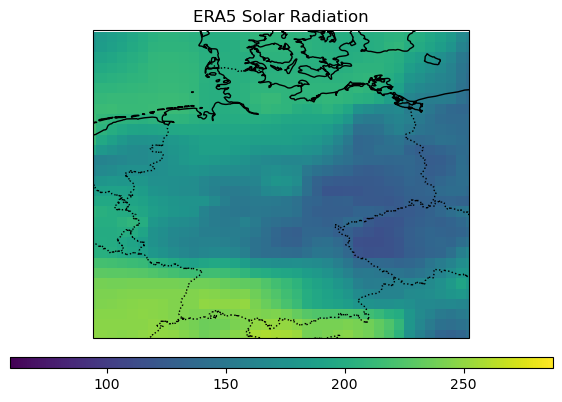

In [11]:
SSRD_pl = datasets_by_variable['SSRD']

timestep = 90
lon_edges = SSRD_pl['lon'].values - (SSRD_pl['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = SSRD_pl['lat'].values - (SSRD_pl['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([5, 16, 47, 56], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.set_title('ERA5 Solar Radiation')

xxx1 = SSRD_pl['var169'].isel(time=timestep)
im1 = ax.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='viridis')
cbar1 = fig.colorbar(im1, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

plt.show()


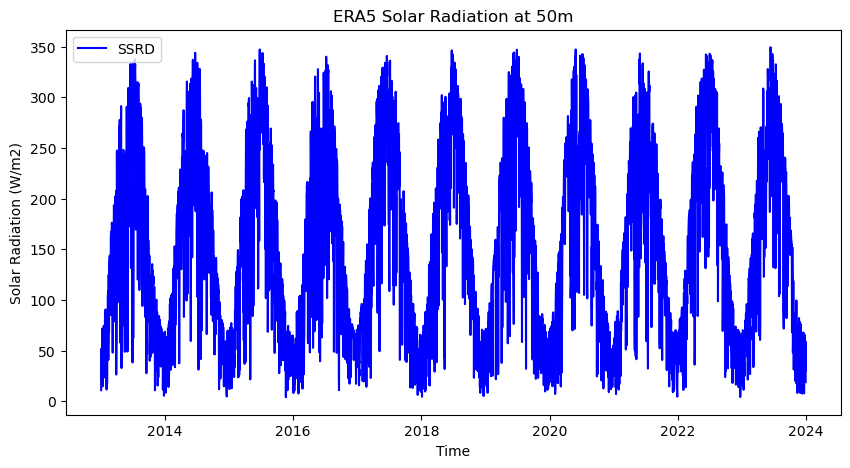

In [12]:
tst = SSRD_pl['var169']
# Plot timeseries of ssrd
fig, ax = plt.subplots(figsize=(10, 5))
tst.isel(lon=10, lat=5).plot(ax=ax, color='blue', label='SSRD')
ax.set_title('ERA5 Solar Radiation at 50m')
ax.set_xlabel('Time')
ax.set_ylabel('Solar Radiation (W/m2)')
ax.legend()
plt.show()

### Prepare data

- rename variables
- regrid data
- calculate windspeed
- convert K to °C

In [13]:
var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    # print(i)
    # print(datasets_by_variable[i])
    # print('------------------')
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(5, 17))
    nc = grid_func.regrid(ds)
    # Append to list for later merging
    ds_list.append(nc)
    # ds.to_netcdf(f'/climca/people/onennecke/ERA5/{i}.nc')

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

In [14]:
clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
clim_ds['tas'] = clim_ds['tas'] - 273.15
clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds
combined_ds

<xarray.Dataset> Size: 12MB
Dimensions:     (time: 4017, lat: 10, lon: 12)
Coordinates:
  * time        (time) datetime64[ns] 32kB 2013-01-01 2013-01-02 ... 2023-12-31
  * lat         (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
    crs         int64 8B 4326
    gridtype    <U6 24B 'lonlat'
  * lon         (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
Data variables:
    rsds        (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
    U100        (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
    V100        (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
    tas         (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
    tasmax      (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
    wind_speed  (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### Run model

In [15]:
wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['wind_speed'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['wind_speed'], grid_onsh_hub_height, config.a_onshore, config.height_ref)

combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']

weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']

sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['wind_speed'])

# combined_ds['solar_pot'] = sepot['solar_pot']
combined_ds['solar_pot'] = sepot

seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

# combined_ds['solar_prod'] = seprod['solar_prod']
combined_ds['solar_prod'] = seprod

In [ ]:
# Calculate weighted sum

weighted_temp_list = []
for y in np.unique(combined_ds['tas']["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
ds_weighted_temp.load()

In [ ]:
ds_weighted_temp_w = xr.concat(
    [
        ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] < 5, drop=True),
        ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] >= 5, drop=True),
    ],
    "period",
)

ds_weighted_temp_w["period"] = ["weekday", "weekend"]
ds_weighted_temp_w.load()

<xarray.Dataset> Size: 97kB
Dimensions:   (period: 2, time: 4017)
Coordinates:
  * time      (time) datetime64[ns] 32kB 2013-01-01 2013-01-02 ... 2023-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
  * period    (period) <U7 56B 'weekday' 'weekend'
Data variables:
    temp      (period, time) float64 64kB dask.array<chunksize=(1, 1), meta=np.ndarray>

In [114]:
# Calculate demand

# Calculate demand during weekdays
demand_weekday = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekday'), demand_fit_values.sel(country = 9, period = 'weekday'))
# Calculate demand during weekends
demand_weekend = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekend'), demand_fit_values.sel(country = 9, period = 'weekend'))
# Combine both datasets
demand_ds = (demand_weekday).fillna(0) + (demand_weekend).fillna(0)

# Averaged demand (prob not used)
demand_week = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))

In [116]:
timeseries_ds = demand_ds.copy()

timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

ts_output = timeseries_ds # .assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
# print('Load')
ts_output.load()
# print('Saving')
ts_output.to_netcdf(f'/climca/people/onennecke/model_output/ERA5_timeseries_cor.nc')

# print('Finished saving')


### Some demand checking

In [117]:
# Calculate ratio from approximated demand with one fit value and the demand values with two fit values
a = demand_weekday['demand'].sum(skipna=True).values + demand_weekend['demand'].sum(skipna=True).values
b = demand_week['demand'].sum(skipna=True).values
c = demand_weekday['demand'][0:10].sum(skipna=True).values + demand_weekend['demand'][0:10].sum(skipna=True).values
d = demand_week['demand'][0:10].sum(skipna=True).values
print(a/b)
print(c/d)

0.9992688099225909
1.0157068505730402


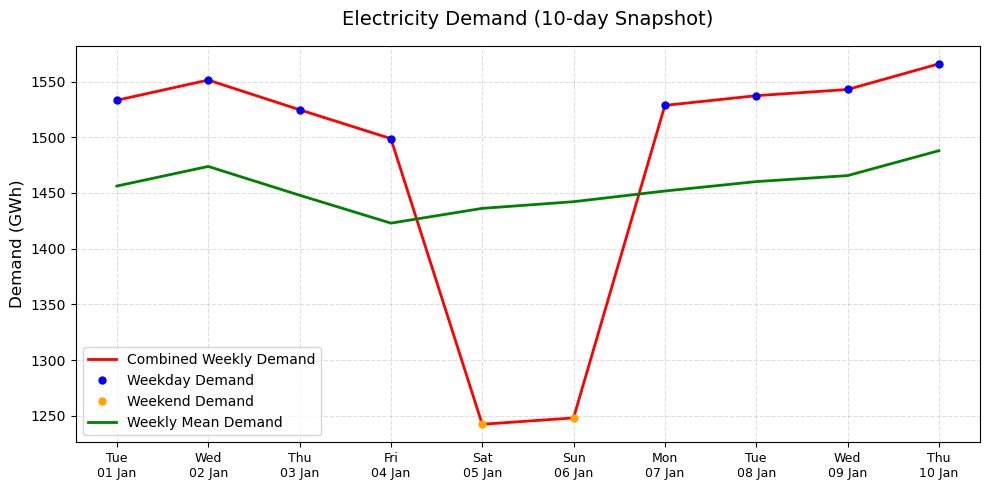

In [118]:
# Compare the different demand curves
fig, ax = plt.subplots(figsize=(10, 5))

demand_ds['demand'][0:10].plot(ax=ax, color='red', label='Combined Weekly Demand', linewidth=2)
demand_weekday['demand'][0:10].plot(ax=ax, color='blue', label='Weekday Demand', marker='o', linestyle='', markersize=5)
demand_weekend['demand'][0:10].plot(ax=ax, color='orange', label='Weekend Demand', marker='o', linestyle='', markersize=5)
demand_week['demand'][0:10].plot(ax=ax, color='green', label='Weekly Mean Demand', linewidth=2)

# Format x-axis as short weekday + date
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)

# Add grid for readability
ax.grid(True, linestyle='--', alpha=0.4)

# Title and labels
ax.set_title('Electricity Demand (10-day Snapshot)', fontsize=14, pad=15)
ax.set_ylabel('Demand (GWh)', fontsize=12)
ax.set_xlabel('')  # Remove label; already included in tick formatting

# Custom legend
ax.legend(frameon=True, fontsize=10, loc='lower left')

# Tight layout
plt.tight_layout()
plt.show()

#### Some plots to check everything is alright

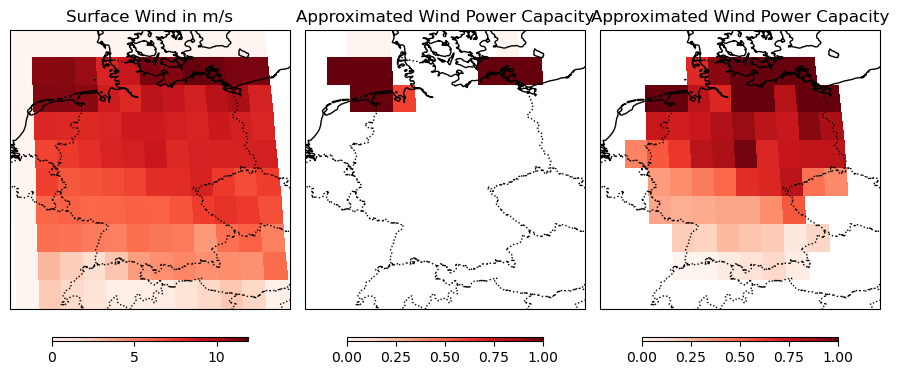

In [119]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = combined_ds['lon'].values - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 1

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['wind_speed'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['wind_off_pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['wind_on_pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()


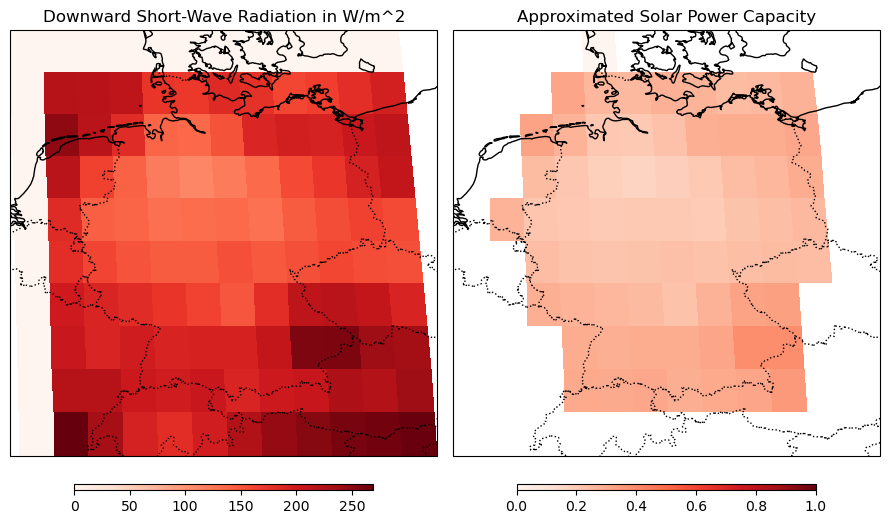

In [120]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot.where(grid_solar > 0)

# '''
lon_edges = combined_ds['lon'].values - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 180 #29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

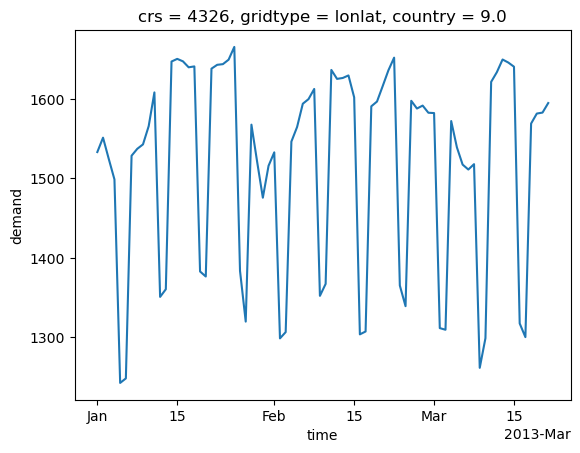

In [121]:
demand_ds['demand'][0:80].plot()

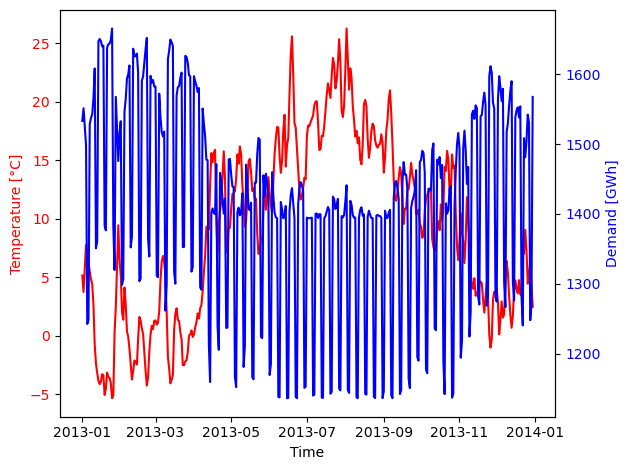

In [122]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

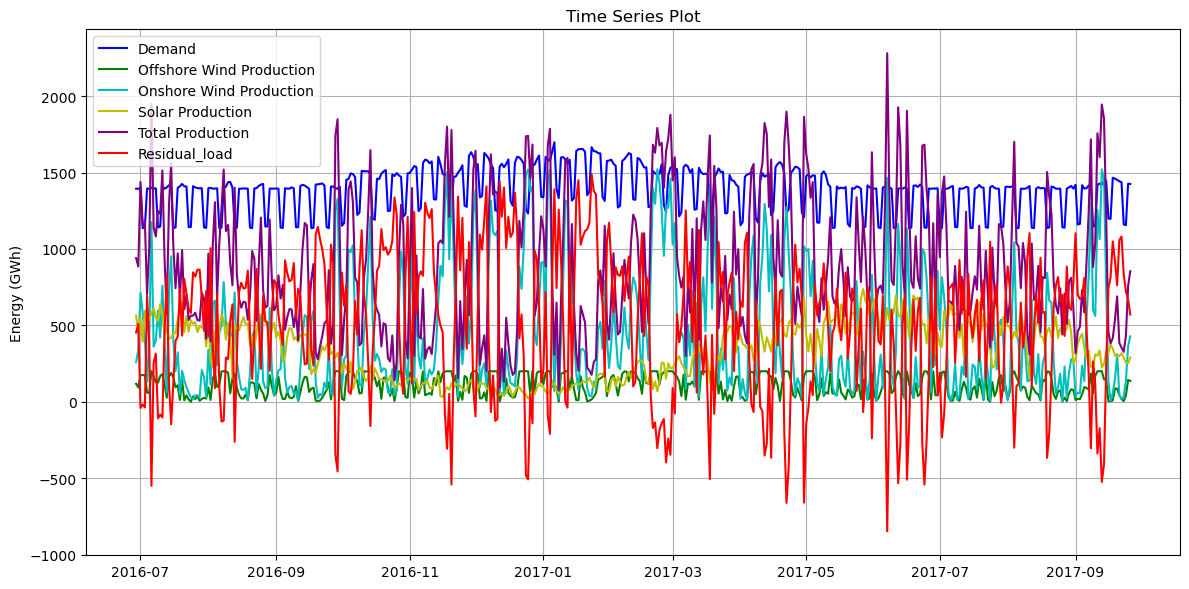

In [123]:

# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
# a = 0
# b = 364
a = 365 * 3 + 6 * 30
b = 365 * 4 + 9 * 30

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

